In [1]:
import sqlite3
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from category_encoders import OneHotEncoder
from IPython.display import VimeoVideo
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.utils.validation import check_is_fitted

warnings.simplefilter(action="ignore", category=FutureWarning)

In [ ]:
%load_ext sql
%sql sqlite:////home/jovyan/nepal.sqlite

In [ ]:
%%sql
SELECT * 
FROM household_demographics
LIMIT 5

household_id	gender_household_head	age_household_head	caste_household	education_level_household_head	income_level_household	size_household	is_bank_account_present_in_household
101	Male	31.0	Rai	Illiterate	Rs. 10 thousand	3.0	0.0
201	Female	62.0	Rai	Illiterate	Rs. 10 thousand	6.0	0.0
301	Male	51.0	Gharti/Bhujel	Illiterate	Rs. 10 thousand	13.0	0.0
401	Male	48.0	Gharti/Bhujel	Illiterate	Rs. 10 thousand	5.0	0.0
501	Male	70.0	Gharti/Bhujel	Illiterate	

In [ ]:
%%sql
SELECT count(*) 
FROM household_demographics
LIMIT 5

%%sql
SELECT count(*) 
FROM household_demographics
LIMIT 5

In [ ]:
%%sql
SELECT * 
FROM id_map
LIMIT 5


Running query in 'sqlite:////home/jovyan/nepal.sqlite'
household_id	building_id	vdcmun_id	district_id
5601	56	7	1
6301	63	7	1
9701	97	7	1
9901	99	7	1
11501	115	7	1


In [ ]:
%%sql
SELECT h.*,
       s.*,
       i.vdcmun_id,
       d.damage_grade
FROM household_demographics AS h
JOIN id_map AS i ON i.household_id =h.household_id
JOIN building_structure AS s ON i.building_id = s.building_id
JOIN building_damage AS d ON i.building_id = d.building_id
WHERE district_id = 4
LIMIT 5

household_id	gender_household_head	age_household_head	caste_household	education_level_household_head	income_level_household	size_household	is_bank_account_present_in_household	building_id	count_floors_pre_eq	count_floors_post_eq	age_building	plinth_area_sq_ft	height_ft_pre_eq	height_ft_post_eq	land_surface_condition	foundation_type	roof_type	ground_floor_type	other_floor_type	position	plan_configuration	condition_post_eq	superstructure	vdcmun_id	damage_grade
16400201	Female	46.0	Chhetree	Class 5	Rs. 10-20 thousand	4.0	1.0	164002	3	3	20	560	18	18	Flat	Mud mortar-Stone/Brick	Bamboo/Timber-Light roof	Mud	TImber/Bamboo-Mud	Not attached	Rectangular	Damaged-Repaired and used	Stone, mud mortar	38	Grade 2
16408101	Male	66.0	Chhetree	Illiterate	Rs. 10 thousand	5.0	0.0	164081	2	2	21	200	12	12	Flat	Mud mortar-Stone/Brick	Bamboo/Timber-Light roof	Mud	TImber/Bamboo-Mud	Not attached	Rectangular	Damaged-Used in risk	Stone, mud mortar	38	Grade 2
16408901	Male	54.0	Magar	Class 4	Rs. 10 thousand	5.0	1.0	164089	3	3	18	315	20	20	Flat	Mud mortar-Stone/Brick	Bamboo/Timber-Light roof	Mud	TImber/Bamboo-Mud	Not attached	Rectangular	Damaged-Used in risk	Stone, mud mortar	38	Grade 2
16409801	Male	36.0	Chhetree	Class 5	Rs. 10 thousand	6.0	1.0	164098	2	2	45	290	13	13	Flat	Mud mortar-Stone/Brick	Bamboo/Timber-Light roof	Mud	TImber/Bamboo-Mud	Not attached	Rectangular	Damaged-Used in risk	Stone, mud mortar	38	Grade 3
16410301	Female	39.0	Chhetree	Class 4	Rs. 10 thousand	

In [ ]:
def wrangle(db_path):
    # Connect to database
    conn = sqlite3.connect(db_path)

    # Construct query
    query = """SELECT h.*,
       s.*,
       i.vdcmun_id,
       d.damage_grade
FROM household_demographics AS h
JOIN id_map AS i ON i.household_id =h.household_id
JOIN building_structure AS s ON i.building_id = s.building_id
JOIN building_damage AS d ON i.building_id = d.building_id
WHERE district_id = 4
"""

    # Read query results into DataFrame
    df = pd.read_sql(query,conn, index_col="household_id")

    # Identify leaky columns
    drop_cols = [col for col in df.columns if "post_eq" in col]

    # Add high-cardinality / redundant column
    drop_cols.append("building_id")

    # Create binary target column
    df["damage_grade"] = df["damage_grade"].str[-1].astype(int)
    df["severe_damage"] = (df["damage_grade"] > 3).astype(int)

    # Drop old target
    drop_cols.append("damage_grade")

    # Drop multicollinearity column
    drop_cols.append("count_floors_pre_eq")
    
    # Drop columns
    df.drop(columns=drop_cols, inplace=True)

    return df

In [ ]:
df = wrangle("/home/jovyan/nepal.sqlite")
df.head()

In [17]:
#LOCAL WRANGLE
def wrangle():
    df = pd.read_csv("data/demographics.csv")

    # Set 'household_id' as index
    df.set_index("household_id", inplace=True)

    # Identify and remove leaky features
    drop_cols = [col for col in df.columns if "post_eq" in col]
    df.drop(columns=drop_cols, inplace=True)

    # Binary classification of target
    df['damage_grade'] = df["damage_grade"].str[-1].astype(int)
    df['severe_damage'] = (df['damage_grade'] > 3).astype(int)
    df.drop(columns=['damage_grade'], inplace=True)

    #Multicollinearity Columns drop
    df.drop(columns=['count_floors_pre_eq'], inplace=True)

    #High Cardinality
    df.drop(columns=['building_id'],inplace=True)


    return df

In [18]:
df = wrangle()
df.head()
df.columns

Index(['gender_household_head', 'age_household_head', 'caste_household',
       'education_level_household_head', 'income_level_household',
       'size_household', 'is_bank_account_present_in_household',
       'age_building', 'plinth_area_sq_ft', 'height_ft_pre_eq',
       'land_surface_condition', 'foundation_type', 'roof_type',
       'ground_floor_type', 'other_floor_type', 'position',
       'plan_configuration', 'superstructure', 'vdcmun_id', 'severe_damage'],
      dtype='object')

In [19]:
# Check your work
assert df.shape == (75883, 20), f"`df` should have shape (75883, 20), not {df.shape}"

In [21]:
# Check for high- and low-cardinality categorical features
df.select_dtypes("object").nunique()

gender_household_head              2
caste_household                   63
education_level_household_head    19
income_level_household             5
land_surface_condition             3
foundation_type                    5
roof_type                          3
ground_floor_type                  5
other_floor_type                   4
position                           4
plan_configuration                10
superstructure                    11
dtype: int64

In [22]:
df["caste_household"].nunique()

63

In [23]:
df["caste_household"].value_counts().head(10)

caste_household
Gurung          15119
Brahman-Hill    13043
Chhetree         8766
Magar            8180
Sarki            6052
Newar            5906
Kami             3565
Tamang           2396
Kumal            2271
Damai/Dholi      1977
Name: count, dtype: int64

In [24]:
df["caste_household"].value_counts().tail(15)

caste_household
Thami            2
Teli             2
Kanu             2
Dhanuk           2
Rajbansi         2
Kewat            2
Thakali          2
Hajam/Thakur     2
Kayastha         1
Satar/Santhal    1
Byasi/Sauka      1
Kalar            1
Dhimal           1
Kalwar           1
Hyolmo           1
Name: count, dtype: int64

In [25]:
top_10 = df["caste_household"].value_counts().head(10).index
df["caste_household"].apply(lambda c: c if c in top_10 else "Other")

household_id
16400201    Chhetree
16408101    Chhetree
16408901       Magar
16409801    Chhetree
16410301    Chhetree
              ...   
23477401       Other
23480801       Other
23482101       Other
23482801       Other
23483501       Other
Name: caste_household, Length: 75883, dtype: object

In [26]:
df["caste_household"].apply(lambda c: c if c in top_10 else "Other").value_counts()

caste_household
Gurung          15119
Brahman-Hill    13043
Chhetree         8766
Other            8608
Magar            8180
Sarki            6052
Newar            5906
Kami             3565
Tamang           2396
Kumal            2271
Damai/Dholi      1977
Name: count, dtype: int64

In [27]:
#LOCAL WRANGLE
def wrangle():
    df = pd.read_csv("data/demographics.csv")

    # Set 'household_id' as index
    df.set_index("household_id", inplace=True)

    # Identify and remove leaky features
    drop_cols = [col for col in df.columns if "post_eq" in col]
    df.drop(columns=drop_cols, inplace=True)

    # Binary classification of target
    df['damage_grade'] = df["damage_grade"].str[-1].astype(int)
    df['severe_damage'] = (df['damage_grade'] > 3).astype(int)
    df.drop(columns=['damage_grade'], inplace=True)

    #Multicollinearity Columns drop
    df.drop(columns=['count_floors_pre_eq'], inplace=True)

    #High Cardinality
    df.drop(columns=['building_id'],inplace=True)

    #Caste Household reduce cardinality
    top_10 = df["caste_household"].value_counts().head(10).index
    df["caste_household"] = df["caste_household"].apply(lambda c: c if c in top_10 else "Other");


    return df

In [28]:
df = wrangle()
df.head()

,gender_household_head,age_household_head,caste_household,education_level_household_head,income_level_household,size_household,is_bank_account_present_in_household,age_building,plinth_area_sq_ft,height_ft_pre_eq,land_surface_condition,foundation_type,roof_type,ground_floor_type,other_floor_type,position,plan_configuration,superstructure,vdcmun_id,severe_damage
household_id,,,,,,,,,,,,,,,,,,,,
16400201,Female,46.0,Chhetree,Class 5,Rs. 10-20 thousand,4.0,1.0,20,560,18,Flat,Mud mortar-Stone/Brick,Bamboo/Timber-Light roof,Mud,TImber/Bamboo-Mud,Not attached,Rectangular,"Stone, mud mortar",38,0
16408101,Male,66.0,Chhetree,Illiterate,Rs. 10 thousand,5.0,0.0,21,200,12,Flat,Mud mortar-Stone/Brick,Bamboo/Timber-Light roof,Mud,TImber/Bamboo-Mud,Not attached,Rectangular,"Stone, mud mortar",38,0
16408901,Male,54.0,Magar,Class 4,Rs. 10 thousand,5.0,1.0,18,315,20,Flat,Mud mortar-Stone/Brick,Bamboo/Timber-Light roof,Mud,TImber/Bamboo-Mud,Not attached,Rectangular,"Stone, mud mortar",38,0
16409801,Male,36.0,Chhetree,Class 5,Rs. 10 thousand,6.0,1.0,45,290,13,Flat,Mud mortar-Stone/Brick,Bamboo/Timber-Light roof,Mud,TImber/Bamboo-Mud,Not attached,Rectangular,"Stone, mud mortar",38,0
16410301,Female,39.0,Chhetree,Class 4,Rs. 10 thousand,3.0,0.0,21,230,13,Flat,Mud mortar-Stone/Brick,Bamboo/Timber-Light roof,Mud,TImber/Bamboo-Mud,Not attached,Rectangular,"Stone, mud mortar",38,0


In [29]:
# Check your work
assert (
    df["caste_household"].nunique() == 11
), f"The `'caste_household'` column should only have 11 unique values, not {df['caste_household'].nunique()}."

In [30]:
target = "severe_damage"
X = df.drop(columns=[target, "vdcmun_id"])
y = df[target]

In [31]:
# Check your work
assert X.shape == (75883, 18), f"The shape of `X` should be (75883, 18), not {X.shape}."
assert "vdcmun_id" not in X.columns, "There should be no `'vdcmun_id'` column in `X`."
assert y.shape == (75883,), f"The shape of `y` should be (75883,), not {y.shape}."

In [32]:
X_train, X_test, y_train, y_test =  train_test_split(X, y, test_size=0.2, random_state=42)

In [33]:
# Check your work
assert X_train.shape == (
    60706,
    18,
), f"The shape of `X_train` should be (60706, 18), not {X_train.shape}."
assert y_train.shape == (
    60706,
), f"The shape of `y_train` should be (60706,), not {y_train.shape}."
assert X_test.shape == (
    15177,
    18,
), f"The shape of `X_test` should be (15177, 18), not {X_test.shape}."
assert y_test.shape == (
    15177,
), f"The shape of `y_test` should be (15177,), not {y_test.shape}."

In [34]:
acc_baseline = y_train.value_counts(normalize=True).max()
print("Baseline Accuracy:", round(acc_baseline, 2))

Baseline Accuracy: 0.63


In [36]:
#Build Logistic Model
model_lr = make_pipeline(
    OneHotEncoder(use_cat_names=True),
    LogisticRegression(max_iter=10000)
)
# Fit model to training data
model_lr.fit(X_train, y_train);

In [37]:
# Check your work
assert isinstance(
    model_lr, Pipeline
), f"`model_lr` should be a Pipeline, not type {type(model_lr)}."
assert isinstance(
    model_lr[0], OneHotEncoder
), f"The first step in your Pipeline should be a OneHotEncoder, not type {type(model_lr[0])}."
assert isinstance(
    model_lr[-1], LogisticRegression
), f"The last step in your Pipeline should be LogisticRegression, not type {type(model_lr[-1])}."
check_is_fitted(model_lr)

In [39]:
acc_train = accuracy_score(y_train, model_lr.predict(X_train))
acc_test = model_lr.score(X_test, y_test)

print("LR Training Accuracy:", acc_train)
print("LR Validation Accuracy:", acc_test)

LR Training Accuracy: 0.7184957005897276
LR Validation Accuracy: 0.7216182381234764


In [40]:
features = model_lr.named_steps["onehotencoder"].get_feature_names()
importances =  model_lr.named_steps["logisticregression"].coef_[0]
feat_imp = pd.Series(np.exp(importances),index=features).sort_values()
feat_imp.head()

superstructure_Other                   0.207216
superstructure_RC, engineered          0.326146
foundation_type_RC                     0.370002
roof_type_RCC/RB/RBC                   0.422208
superstructure_Brick, cement mortar    0.429087
dtype: float64

Text(0.5, 0, 'Odds Ratio')

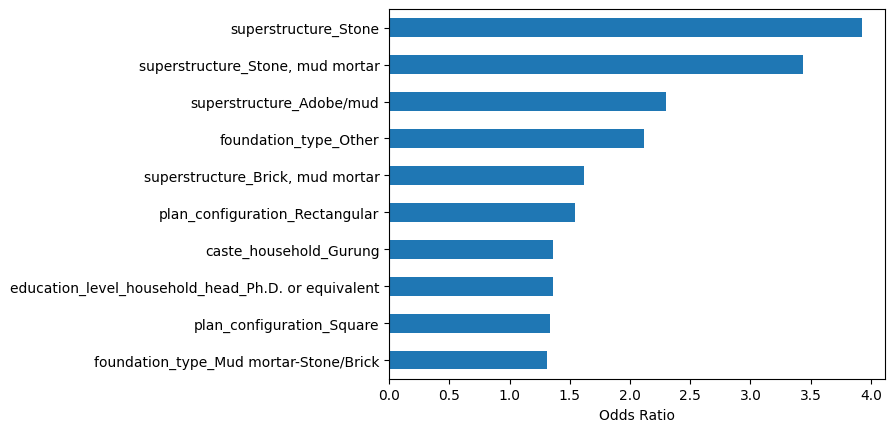

In [41]:
feat_imp.tail(10).plot(kind="barh")
plt.xlabel("Odds Ratio")

Text(0.5, 0, 'Odds Ratio')

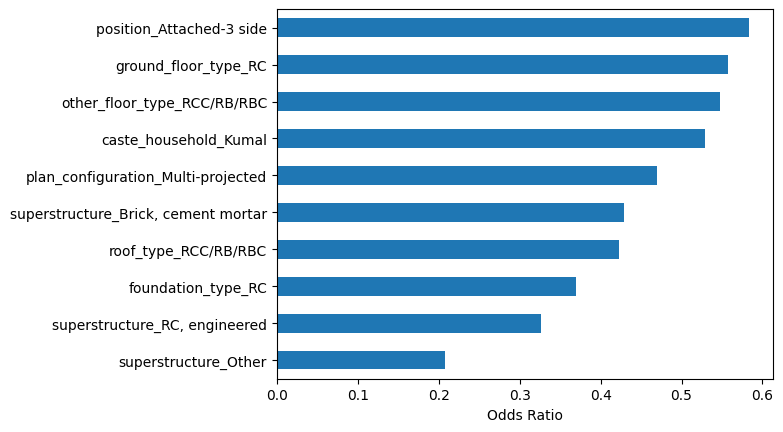

In [42]:
feat_imp.head(10).plot(kind="barh")
plt.xlabel("Odds Ratio")

We can see that caste_household_Gurung and caste_household_Kumal are shown in Odds Ratio graphs which is surprising as people inside the house don't affect what damage happens to the house in a earthquake!